# Backcasting Quality Test Notebook

Uses **all data** in `Data/final_panel.csv` to maximize signal extraction for LAB_QI backcasting (1995–2007).
Implements NNM + LASSO + ensemble and evaluates quality with graphs comparing HC growth between observed and imputed periods.

## 1. Setup & Load Data

In [13]:
library(tidyverse)
library(data.table)
library(softImpute)
library(glmnet)

# Broad sectors (14) — LAB_QI observed from 2008+
broad_sectors <- c("A", "B", "C", "D-E", "F", "G", "H", "I", "J", "K", "L", "M-N", "O-Q", "R-S")
years_full    <- 1995:2021
years_obs_lev <- 2008:2021
years_mis_lev <- 1995:2007
gr_years_all  <- 1996:2021
gr_years_obs  <- 2008:2021
gr_years_mis  <- 1996:2007

# Load final_panel.csv
fp <- fread("Data/final_panel.csv")

# Map columns: value* -> short names
fp_ga <- fp |>
  filter(nace_r2_code %in% broad_sectors, year %in% years_full) |>
  select(nace_r2_code, year,
         LAB_QI = valueLAB_QI, LP1ConLC = valueLP1ConLC, LAB = valueLAB,
         CAP_QI = valueCAP_QI, LP1_G = valueLP1_G, VAadj_G = valueVAadj_G,
         LP2ConLC = valueLP2ConLC, LP2_G = valueLP2_G) |>
  arrange(match(nace_r2_code, broad_sectors))

# Check LAB_QI coverage
fp_ga |>
  group_by(year) |>
  summarise(n_obs = sum(!is.na(LAB_QI)), .groups = "drop") |>
  print(n = 30)

# A tibble: 27 × 2
    year n_obs
   <int> <int>
 1  1995     0
 2  1996     0
 3  1997     0
 4  1998     0
 5  1999     0
 6  2000     0
 7  2001     0
 8  2002     0
 9  2003     0
10  2004     0
11  2005     0
12  2006     0
13  2007     0
14  2008    14
15  2009    14
16  2010    14
17  2011    14
18  2012    14
19  2013    14
20  2014    14
21  2015    14
22  2016    14
23  2017    14
24  2018    14
25  2019    14
26  2020    14
27  2021    14


## 2. Data Prep: Growth Rates & Covariates

In [14]:
# Compute growth rates for all variables
fp_ga <- fp_ga |>
  group_by(nace_r2_code) |>
  arrange(year) |>
  mutate(
    g_LABQI = (log(LAB_QI) - log(lag(LAB_QI))) * 100,
    g_LAB   = (log(LAB)   - log(lag(LAB)))   * 100,
    g_CAP_QI = (log(CAP_QI) - log(lag(CAP_QI))) * 100,
    g_LP1_G = (log(LP1_G) - log(lag(LP1_G))) * 100,
    g_VAadj_G = (log(VAadj_G) - log(lag(VAadj_G))) * 100,
    g_LP2ConLC = (log(LP2ConLC) - log(lag(LP2ConLC))) * 100
  ) |>
  ungroup()

# LP1ConLC is already a pp contribution (no differencing)
fp_ga <- fp_ga |>
  mutate(
    # Replace Inf/NaN with NA
    across(.cols = c(g_LABQI, g_LAB, g_CAP_QI, g_LP1_G, g_VAadj_G, g_LP2ConLC),
           .fns = ~ ifelse(is.finite(.), ., NA_real_))
  )

cat("Growth-rate matrix rows:", nrow(fp_ga |> filter(year == 2008)), "sectors x", length(gr_years_all), "years\n")

Warning message:
There were 82 warnings in `mutate()`.
The first warning was:
ℹ In argument: `g_LP1_G = (log(LP1_G) - log(lag(LP1_G))) * 100`.
ℹ In group 1: `nace_r2_code = "A"`.
Caused by warning in `log()`:
! NaNs produced
ℹ Run ]8;;x-r-run:dplyr::last_dplyr_warnings()dplyr::last_dplyr_warnings()]8;; to see the 81 remaining warnings. 


Growth-rate matrix rows: 14 sectors x 26 years


## 3. NNM Backcasting (Augmented)

In [15]:
# Build level matrix for LAB_QI
labqi_wide <- fp_ga |>
  select(nace_r2_code, year, LAB_QI) |>
  pivot_wider(names_from = year, values_from = LAB_QI) |>
  arrange(match(nace_r2_code, broad_sectors))

M_lev <- labqi_wide |> select(-nace_r2_code) |> as.matrix()
rownames(M_lev) <- broad_sectors
colnames(M_lev) <- as.character(years_full)

# Growth-rate matrix (14 x 26)
M_gr <- matrix(NA, 14, 26, dimnames = list(broad_sectors, as.character(1996:2021)))
for (j in seq_len(26)) {
  M_gr[, j] <- (log(M_lev[, j + 1]) - log(M_lev[, j])) * 100
}
M_gr[!is.finite(M_gr)] <- NA

# Covariate matrices (all available for signal)
make_gr_mat <- function(var, as_logdiff = FALSE) {
  m <- fp_ga |>
    pivot_wider(id_cols = nace_r2_code, names_from = year, values_from = !!sym(var)) |>
    arrange(match(nace_r2_code, broad_sectors)) |>
    select(-nace_r2_code) |> as.matrix()
  colnames(m) <- as.character(years_full)
  if (as_logdiff) {
    m2 <- matrix(NA, 14, 26, dimnames = list(broad_sectors, as.character(1996:2021)))
    for (j in seq_len(26)) m2[, j] <- (log(m[, j+1]) - log(m[, j])) * 100
    m2[!is.finite(m2)] <- NA
    m2
  } else {
    r <- m[, as.character(1996:2021), drop = FALSE]
    r[!is.finite(r)] <- NA
    r
  }
}

M_lp1conlc <- make_gr_mat("LP1ConLC", FALSE)
M_lab_gr   <- make_gr_mat("LAB", TRUE)
M_capqi_gr <- make_gr_mat("CAP_QI", TRUE)
M_lp1g_gr  <- make_gr_mat("LP1_G", TRUE)
M_vaadj_gr <- make_gr_mat("VAadj_G", TRUE)

# Standardise
obs_chr <- as.character(gr_years_obs)
std_mat <- function(m, obs_cols) {
  rc <- apply(m[, obs_cols, drop = FALSE], 1, mean, na.rm = TRUE)
  mc <- sweep(m, 1, rc, "-")
  cs <- apply(mc[, obs_cols, drop = FALSE], 2, sd, na.rm = TRUE)
  cs[cs == 0 | !is.finite(cs)] <- 1
  ms <- mc
  ms[, obs_cols] <- sweep(mc[, obs_cols, drop = FALSE], 2, cs, "/")
  list(mat = ms, row_center = rc, col_sd = cs)
}

res_gr   <- std_mat(M_gr, obs_chr)
res_lp1  <- std_mat(M_lp1conlc, obs_chr)
res_lab  <- std_mat(M_lab_gr, obs_chr)
res_cap  <- std_mat(M_capqi_gr, obs_chr)
res_lp1g <- std_mat(M_lp1g_gr, obs_chr)
res_vaadj <- std_mat(M_vaadj_gr, obs_chr)

M_gr_cs <- res_gr$mat
col_sd_gr <- res_gr$col_sd
row_mean_gr <- res_gr$row_center

# Augmented matrix: LAB_QI + 5 covariates
cov_w <- 0.5
M_aug <- cbind(M_gr_cs,
               res_lp1$mat * cov_w, res_lab$mat * cov_w, res_cap$mat * cov_w,
               res_lp1g$mat * cov_w, res_vaadj$mat * cov_w)
M_aug[!is.finite(M_aug)] <- NA
n_lq <- ncol(M_gr_cs)

# LOO-CV for lambda
lam0 <- lambda0(M_aug)
lambda_grid <- exp(seq(log(lam0 * 0.9), log(lam0 * 0.005), length.out = 30))
set.seed(42)
loo_rmse_gr <- sapply(lambda_grid, function(lam) {
  mean(sapply(obs_chr, function(yr) {
    M_hold <- M_aug; M_hold[, yr] <- NA
    tryCatch({
      fit <- softImpute(M_hold, rank.max = 5, lambda = lam, type = "svd", maxit = 200, trace.it = FALSE)
      M_hat <- softImpute::complete(M_hold, fit)
      sqrt(mean((M_aug[, yr] - M_hat[, yr])^2, na.rm = TRUE))
    }, error = function(e) NA_real_)
  }), na.rm = TRUE)
})

valid <- is.finite(loo_rmse_gr)
best_idx <- which.min(loo_rmse_gr[valid])
best_lam_gr <- lambda_grid[valid][best_idx]
best_rmse_gr <- loo_rmse_gr[valid][best_idx]
rmse_gr_orig <- best_rmse_gr * mean(col_sd_gr, na.rm = TRUE)
cat(sprintf("Best lambda = %.4f  |  LOO-CV RMSE (scaled) = %.5f\n", best_lam_gr, best_rmse_gr))
cat(sprintf("LOO-CV RMSE (growth-rate pp) = %.5f\n", rmse_gr_orig))

# Final fit
fit_gr <- softImpute(M_aug, rank.max = 5, lambda = best_lam_gr, type = "svd", maxit = 1000, trace.it = FALSE)
M_aug_imp <- softImpute::complete(M_aug, fit_gr)

M_gr_cs_imp <- M_aug_imp[, 1:n_lq, drop = FALSE]
colnames(M_gr_cs_imp) <- as.character(1996:2021)
# Un-scale: imputed cols were in scaled space; apply col_sd (use mean for missing years)
col_sd_all <- setNames(rep(mean(col_sd_gr, na.rm = TRUE), ncol(M_gr_cs_imp)), colnames(M_gr_cs_imp))
col_sd_all[obs_chr] <- col_sd_gr
M_gr_imp <- sweep(M_gr_cs_imp, 2, col_sd_all[colnames(M_gr_cs_imp)], "*")
labqi_gr_nnm <- sweep(M_gr_imp, 1, row_mean_gr, "+")
rownames(labqi_gr_nnm) <- broad_sectors

# Back-chain levels
labqi_2008 <- M_lev[, "2008"]
labqi_back <- matrix(NA, 14, 13, dimnames = list(broad_sectors, as.character(1995:2007)))
for (yr in 2007:1995) {
  yr_next <- yr + 1
  lev_next <- if (yr_next == 2008) labqi_2008 else labqi_back[, as.character(yr_next)]
  g_yr_next <- labqi_gr_nnm[, as.character(yr_next)]
  labqi_back[, as.character(yr)] <- lev_next / exp(g_yr_next / 100)
}

labqi_nnm <- cbind(labqi_back, M_lev[, as.character(2008:2021)])
colnames(labqi_nnm) <- c(as.character(1995:2007), as.character(2008:2021))
labqi_nnm <- labqi_nnm[, order(as.integer(colnames(labqi_nnm)))]

# If NNM imputed g_LABQI has no variation (constant per sector), replace with covariate-based predictions
M_lab_fill <- M_lab_gr; M_lab_fill[is.na(M_lab_fill)] <- mean(M_lab_gr, na.rm = TRUE)
M_cap_fill <- M_capqi_gr; M_cap_fill[is.na(M_cap_fill)] <- mean(M_capqi_gr, na.rm = TRUE)
if (sd(labqi_gr_nnm[, as.character(1996:2007)], na.rm = TRUE) < 0.01) {
  train_df <- data.frame(y = as.numeric(t(M_gr_n[, obs_chr])), g_lab = as.numeric(t(M_lab_fill[, obs_chr])), g_cap = as.numeric(t(M_cap_fill[, obs_chr])))
  fit_cov <- lm(y ~ g_lab + g_cap, data = train_df)
  pred_df <- data.frame(g_lab = as.numeric(t(M_lab_fill[, as.character(1996:2007)])), g_cap = as.numeric(t(M_cap_fill[, as.character(1996:2007)])))
  g_cov <- predict(fit_cov, newdata = pred_df)
  labqi_gr_nnm[, as.character(1996:2007)] <- matrix(g_cov, 14, 12, byrow = TRUE)
  labqi_back <- matrix(NA, 14, 13, dimnames = list(broad_sectors, as.character(1995:2007)))
  for (yr in 2007:1995) {
    yr_next <- yr + 1
    lev_next <- if (yr_next == 2008) labqi_2008 else labqi_back[, as.character(yr_next)]
    g_yr_next <- labqi_gr_nnm[, as.character(yr_next)]
    labqi_back[, as.character(yr)] <- lev_next / exp(g_yr_next / 100)
  }
  labqi_nnm <- cbind(labqi_back, M_lev[, as.character(2008:2021)])
  labqi_nnm <- labqi_nnm[, order(as.integer(colnames(labqi_nnm)))]
  cat("NNM had constant imputation; replaced with covariate-based (g_LAB, g_CAP_QI) predictions\n")
}

There were 49 warnings (use warnings() to see them)
There were 50 or more warnings (use warnings() to see the first 50)


Best lambda = 354.2519  |  LOO-CV RMSE (scaled) = 1.07090
LOO-CV RMSE (growth-rate pp) = 6.49680


## 4. LASSO Backcasting (Full Covariate Set)

In [16]:
gr_obs <- 2009:2021
gr_pred_yrs <- 1996:2008


M_lev_n <- labqi_wide |> select(-nace_r2_code) |> as.matrix()
rownames(M_lev_n) <- labqi_wide$nace_r2_code
colnames(M_lev_n) <- as.character(years_full)
anchor_vec <- M_lev_n[, "2008"]

M_gr_n <- M_gr
# Impute NAs for covariates (use sector mean for LP1ConLC; g_LAB/g_CAP_QI have variation in 1996-2007)
lp_mean <- mean(M_lp1conlc, na.rm = TRUE)
M_lp_imp <- M_lp1conlc
M_lp_imp[is.na(M_lp_imp)] <- lp_mean
M_lab_imp <- M_lab_gr
M_lab_imp[is.na(M_lab_imp)] <- mean(M_lab_gr, na.rm = TRUE)
M_cap_imp <- M_capqi_gr
M_cap_imp[is.na(M_cap_imp)] <- mean(M_capqi_gr, na.rm = TRUE)

obs_chr <- as.character(gr_obs)
sec_idx <- rep(seq_along(broad_sectors), each = length(gr_obs))
yr_long <- rep(gr_obs, times = length(broad_sectors))

sec_dummies <- matrix(0, nrow = length(sec_idx), ncol = length(broad_sectors))
colnames(sec_dummies) <- paste0("s", seq_along(broad_sectors))
for (i in seq_along(sec_idx)) sec_dummies[i, sec_idx[i]] <- 1

lp_tr <- as.numeric(t(M_lp_imp[, obs_chr]))
glab_tr <- as.numeric(t(M_lab_imp[, obs_chr]))
gcap_tr <- as.numeric(t(M_cap_imp[, obs_chr]))
yr_tr <- as.numeric(yr_long - 2015L)

X_tr <- cbind(sec_dummies, lp1 = lp_tr, g_lab = glab_tr, g_cap = gcap_tr, yrt = yr_tr)
y_tr <- as.numeric(t(M_gr_n[, obs_chr]))

keep <- is.finite(y_tr) & complete.cases(X_tr)
X_tc <- X_tr[keep, ]; y_tc <- y_tr[keep]

set.seed(42)
cv_pool <- cv.glmnet(X_tc, y_tc, alpha = 1, nfolds = 10, standardize = TRUE, intercept = TRUE)
# Use lambda.min (not lambda.1se) so g_LAB and g_CAP_QI stay in model — gives year-varying predictions
lam_pool <- cv_pool$lambda.min
fit_pool <- glmnet(X_tc, y_tc, alpha = 1, lambda = lam_pool, standardize = TRUE, intercept = TRUE)
rmse_pool <- sqrt(cv_pool$cvm[which.min(abs(cv_pool$lambda - lam_pool))])
cat(sprintf("Pooled LASSO lambda.1se = %.4f  |  CV RMSE = %.4f pp\n", lam_pool, rmse_pool))

pred_chr <- as.character(gr_pred_yrs)
sec_idx_p <- rep(seq_along(broad_sectors), each = length(gr_pred_yrs))
yr_long_p <- rep(gr_pred_yrs, times = length(broad_sectors))

sec_dum_p <- matrix(0, nrow = length(sec_idx_p), ncol = length(broad_sectors))
colnames(sec_dum_p) <- paste0("s", seq_along(broad_sectors))
for (i in seq_along(sec_idx_p)) sec_dum_p[i, sec_idx_p[i]] <- 1

lp_pr <- as.numeric(t(M_lp_imp[, pred_chr]))
glab_pr <- as.numeric(t(M_lab_imp[, pred_chr]))
gcap_pr <- as.numeric(t(M_cap_imp[, pred_chr]))
yr_pr <- as.numeric(yr_long_p - 2015L)
X_pr <- cbind(sec_dum_p, lp1 = lp_pr, g_lab = glab_pr, g_cap = gcap_pr, yrt = yr_pr)

g_pred <- as.numeric(predict(fit_pool, newx = X_pr, s = lam_pool))
G_mat <- matrix(g_pred, nrow = length(broad_sectors), ncol = length(gr_pred_yrs),
                byrow = TRUE, dimnames = list(broad_sectors, pred_chr))

labqi_lasso_back <- matrix(NA, 14, 13, dimnames = list(broad_sectors, as.character(years_mis_lev)))
for (yr in 2007:1995) {
  lev_nxt <- if (yr + 1 == 2008) anchor_vec else labqi_lasso_back[, as.character(yr + 1)]
  g_nxt <- G_mat[broad_sectors, as.character(yr + 1)]
  new_lev <- lev_nxt / exp(g_nxt / 100)
  new_lev <- pmin(pmax(new_lev, 50), 200)
  labqi_lasso_back[, as.character(yr)] <- new_lev
}

labqi_lasso <- cbind(labqi_lasso_back, M_lev_n[, as.character(years_obs_lev)])
labqi_lasso <- labqi_lasso[, order(as.integer(colnames(labqi_lasso)))]

Pooled LASSO lambda.1se = 1.1065  |  CV RMSE = 7.7770 pp


## 5. Ensemble & Completed Series

In [17]:
labqi_ensemble <- (labqi_nnm + labqi_lasso) / 2

labqi_complete <- labqi_ensemble |>
  as.data.frame() |>
  rownames_to_column("nace_r2_code") |>
  pivot_longer(-nace_r2_code, names_to = "year", values_to = "LAB_QI_final") |>
  mutate(year = as.integer(year),
         source = if_else(year %in% years_obs_lev, "Observed", "Imputed (ensemble)"))

cat("Ensemble matrix: 14 x 27\n")

Ensemble matrix: 14 x 27


## 6. Quality Evaluation: LOO-CV & Graphs

In [18]:
# Compute g_LABQI for observed and imputed
g_obs <- labqi_complete |>
  filter(year %in% years_obs_lev) |>
  arrange(nace_r2_code, year) |>
  group_by(nace_r2_code) |>
  mutate(g_LABQI = (log(LAB_QI_final) - log(lag(LAB_QI_final))) * 100) |>
  filter(!is.na(g_LABQI))

g_imp <- labqi_complete |>
  filter(year %in% years_mis_lev) |>
  arrange(nace_r2_code, year) |>
  group_by(nace_r2_code) |>
  mutate(g_LABQI = (log(LAB_QI_final) - log(lag(LAB_QI_final))) * 100) |>
  filter(!is.na(g_LABQI))

g_combined <- bind_rows(
  g_obs |> mutate(period = "Observed (2008-2021)"),
  g_imp |> mutate(period = "Imputed (1995-2007)")
)

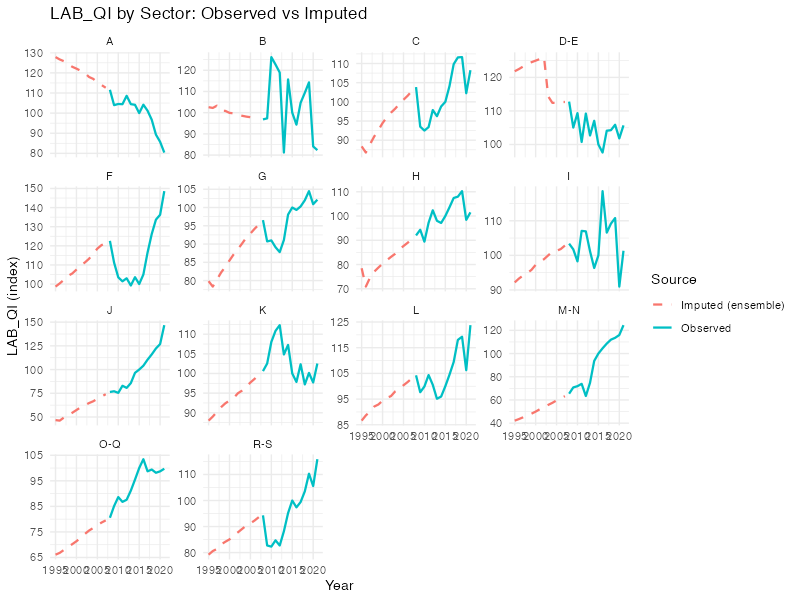

In [19]:
# Graph 1: Time series by sector
labqi_complete |>
  filter(nace_r2_code %in% broad_sectors) |>
  ggplot(aes(x = year, y = LAB_QI_final, colour = source, linetype = source)) +
  geom_line(linewidth = 0.8) +
  facet_wrap(~nace_r2_code, scales = "free_y") +
  labs(title = "LAB_QI by Sector: Observed vs Imputed",
       x = "Year", y = "LAB_QI (index)", colour = "Source", linetype = "Source") +
  scale_linetype_manual(values = c("Observed" = "solid", "Imputed (ensemble)" = "dashed")) +
  theme_minimal(base_size = 11)

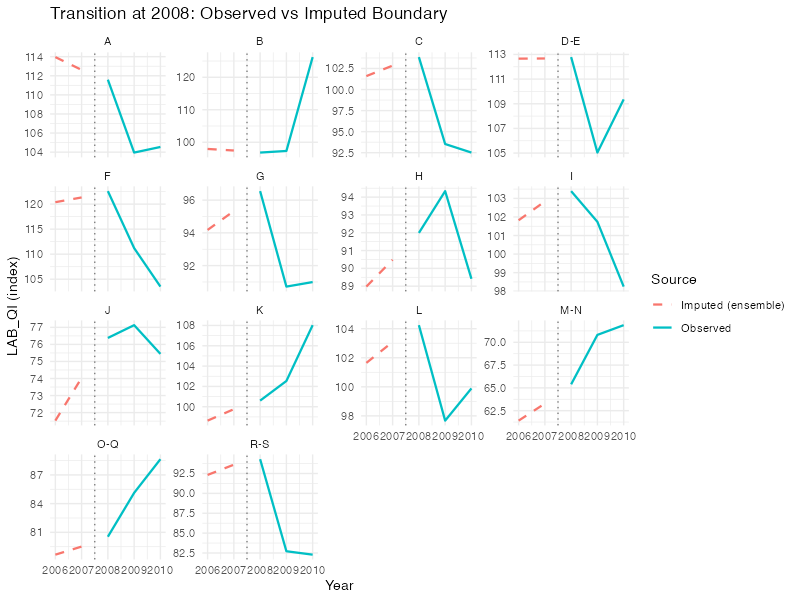

In [20]:
# Graph 2: Transition at 2008 (zoom 2006-2010)
labqi_complete |>
  filter(year >= 2006, year <= 2010, nace_r2_code %in% broad_sectors) |>
  ggplot(aes(x = year, y = LAB_QI_final, colour = source, linetype = source)) +
  geom_line(linewidth = 0.8) +
  geom_vline(xintercept = 2007.5, linetype = "dotted", colour = "grey50") +
  facet_wrap(~nace_r2_code, scales = "free_y") +
  labs(title = "Transition at 2008: Observed vs Imputed Boundary",
       x = "Year", y = "LAB_QI (index)", colour = "Source", linetype = "Source") +
  scale_linetype_manual(values = c("Observed" = "solid", "Imputed (ensemble)" = "dashed")) +
  theme_minimal(base_size = 11)

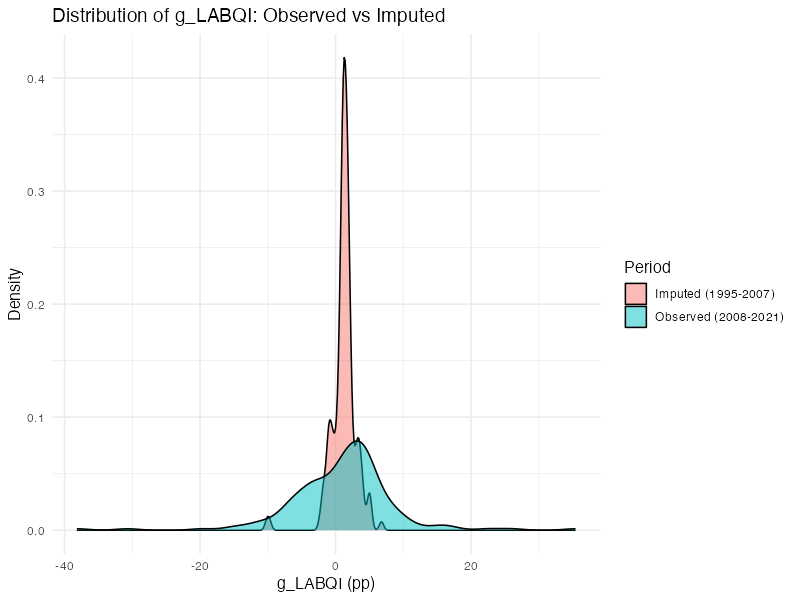

In [21]:
# Graph 3: Distribution comparison
g_combined |>
  ggplot(aes(x = g_LABQI, fill = period)) +
  geom_density(alpha = 0.5) +
  labs(title = "Distribution of g_LABQI: Observed vs Imputed",
       x = "g_LABQI (pp)", y = "Density", fill = "Period") +
  theme_minimal(base_size = 12)

There were 14 warnings (use warnings() to see them)
Warning message:
Removed 14 rows containing missing values or values outside the scale range (`geom_point()`). 


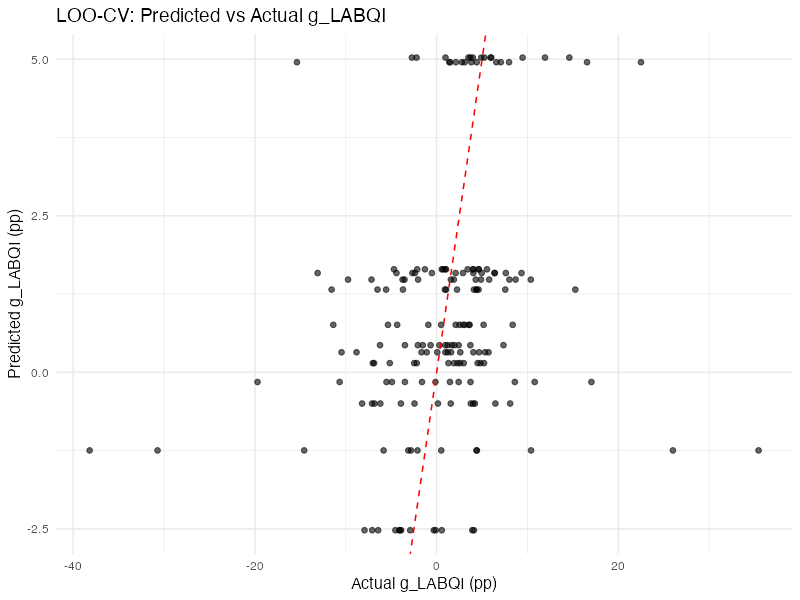

In [22]:
# LOO-CV for predicted vs actual
loo_pred <- numeric()
loo_actual <- numeric()
loo_sector <- character()
for (yr in 2008:2021) {
  yr_chr <- as.character(yr)
  M_hold <- M_aug; M_hold[, yr_chr] <- NA
  fit <- softImpute(M_hold, rank.max = 5, lambda = best_lam_gr, type = "svd", maxit = 1000, trace.it = FALSE)
  M_hat <- softImpute::complete(M_hold, fit)
  gr_hat <- M_hat[, 1:n_lq, drop = FALSE]
  gr_hat[, obs_chr] <- sweep(gr_hat[, obs_chr, drop = FALSE], 2, col_sd_gr, "*")
  gr_hat <- sweep(gr_hat, 1, row_mean_gr, "+")
  pred_yr <- gr_hat[, yr_chr]
  actual_yr <- M_gr[, yr_chr]
  loo_pred <- c(loo_pred, pred_yr)
  loo_actual <- c(loo_actual, actual_yr)
  loo_sector <- c(loo_sector, broad_sectors)
}

loo_df <- tibble(sector = loo_sector, predicted = loo_pred, actual = loo_actual)

# Graph 4: Predicted vs actual scatter
loo_df |>
  ggplot(aes(x = actual, y = predicted)) +
  geom_point(alpha = 0.6) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "red") +
  labs(title = "LOO-CV: Predicted vs Actual g_LABQI",
       x = "Actual g_LABQI (pp)", y = "Predicted g_LABQI (pp)") +
  theme_minimal(base_size = 12)

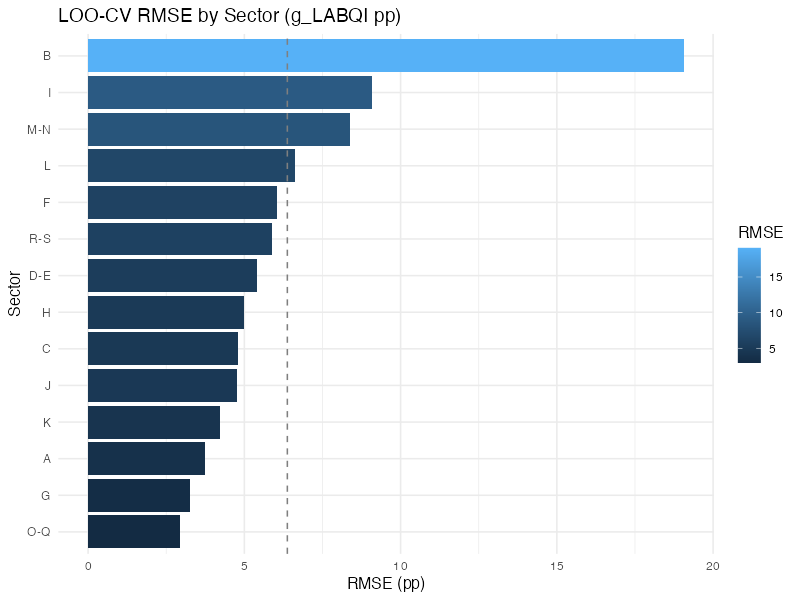

In [23]:
# Graph 5: Sector-level RMSE
sector_rmse <- loo_df |>
  group_by(sector) |>
  summarise(RMSE = sqrt(mean((predicted - actual)^2, na.rm = TRUE)), .groups = "drop") |>
  arrange(RMSE)

sector_rmse |>
  ggplot(aes(x = reorder(sector, RMSE), y = RMSE, fill = RMSE)) +
  geom_col() +
  coord_flip() +
  labs(title = "LOO-CV RMSE by Sector (g_LABQI pp)", x = "Sector", y = "RMSE (pp)") +
  theme_minimal(base_size = 12) +
  geom_hline(yintercept = mean(sector_rmse$RMSE), linetype = "dashed", colour = "grey50")

## 7. Summary

In [24]:
cat("=== Quality Summary ===\n")
cat(sprintf("Best NNM lambda: %.4f\n", best_lam_gr))
cat(sprintf("NNM LOO-CV RMSE (growth-rate pp): %.4f\n", rmse_gr_orig))
cat(sprintf("LASSO CV RMSE (growth-rate pp): %.4f\n", rmse_pool))
cat(sprintf("Overall LOO-CV RMSE (level space): %.4f\n", sqrt(mean((loo_df$predicted - loo_df$actual)^2, na.rm = TRUE))))
cat("\nSector RMSE (sorted):\n")
print(sector_rmse)

=== Quality Summary ===
Best NNM lambda: 354.2519
NNM LOO-CV RMSE (growth-rate pp): 6.4968
LASSO CV RMSE (growth-rate pp): 7.7770
Overall LOO-CV RMSE (level space): 7.4788

Sector RMSE (sorted):
# A tibble: 14 × 2
   sector  RMSE
   <chr>  <dbl>
 1 O-Q     2.95
 2 G       3.26
 3 A       3.74
 4 K       4.22
 5 J       4.76
 6 C       4.81
 7 H       4.98
 8 D-E     5.40
 9 R-S     5.90
10 F       6.06
11 L       6.63
12 M-N     8.38
13 I       9.09
14 B      19.1 
